# ITO5202 Assessment 2 — Machine Learning and Real-Time Streaming

**Student ID:** 29701201  **Unit:** ITO5202
**Dataset:** Brazilian E-Commerce Public Dataset by Olist ([Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce))
| Section | Content |
|---|---|
| Environment setup | Spark session and execution environment |
| Data loading | Eight Olist tables with explicit schemas |
| Before Part A | One record per order, and the reproducible 70/30 train/stream split |
| Part A | ML pipeline: task selection, feature engineering, model comparison, persistence |
| Part B | Kafka producer, Structured Streaming consumer, windowed aggregation, reflection |

## Environment Setup

The Spark configuration is carried over from Assessment 1, so results from the two notebooks are directly comparable:

- `local[*]` uses every core the Docker container exposes.
- `spark.driver.memory = 4g` must be set before the JVM starts, so this cell must be the first Spark call after a kernel restart.
- `spark.sql.session.timeZone = UTC`. Olist timestamps are Brazilian local times with no zone attached. Parsing them in UTC stops the container's time zone from shifting them, which would change delivery durations and the late-delivery flag.
- `spark.sql.shuffle.partitions = 2 × cores`. The order-level table is about 96k rows, so the default 200 shuffle partitions would create mostly empty tasks.

In [3]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
import os          # file paths and CPU count
import platform    # Python / OS version for the environment table
import shutil      # removing old output folders before re-writing them
import pyspark   

import pandas as pd

# Spark configuration and entry points
from pyspark import SparkConf
from pyspark.sql import SparkSession

# DataFrame functions, window specifications and schema types
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import (StructType, StructField, StringType,
                               IntegerType, DoubleType, TimestampType)

In [4]:
# ---------------------------------------------------------------
# Spark configuration
# ---------------------------------------------------------------
master = "local[*]"
app_name = "ITO5202_A2_Olist_29701201"

spark_conf = (
    SparkConf()
    .setMaster(master)
    .setAppName(app_name)
    # In local mode the driver is also the executor, so this is all the
    # memory Spark has. Only takes effect when the JVM starts.
    .set("spark.driver.memory", "4g")
    # Parse timestamps exactly as written in the CSVs (no time-zone shifting)
    .set("spark.sql.session.timeZone", "UTC")
    # Hide console progress bars so the PDF export stays clean
    .set("spark.ui.showConsoleProgress", "false")
    # Kafka connector for Structured Streaming (Part B), matching the Spark version
    .set("spark.jars.packages", f"org.apache.spark:spark-sql-kafka-0-10_2.13:{pyspark.__version__}")
)

spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("ERROR")  # errors only, to keep outputs readable

# 2 x cores: enough tasks to keep every core busy, without 200 near-empty ones
SHUFFLE_PARTITIONS = sc.defaultParallelism * 2
spark.conf.set("spark.sql.shuffle.partitions", SHUFFLE_PARTITIONS)

print(f"Spark {spark.version} session started: {app_name}")
print(f"Shuffle partitions set to {SHUFFLE_PARTITIONS} "
      f"({sc.defaultParallelism} cores x 2)")

Spark 4.1.1 session started: ITO5202_A2_Olist_29701201
Shuffle partitions set to 16 (8 cores x 2)


In [5]:
# ---------------------------------------------------------------
# Execution environment summary
# ---------------------------------------------------------------
env = {
    "Execution mode": f"local ({sc.master})",
    "Spark version": spark.version,
    "Python version": platform.python_version(),
    "OS": f"{platform.system()} {platform.release()}",
    "CPU cores visible": os.cpu_count(),
    "defaultParallelism": sc.defaultParallelism,
    "Driver memory": spark.conf.get("spark.driver.memory", "default (1g)"),
    "spark.sql.shuffle.partitions": spark.conf.get("spark.sql.shuffle.partitions"),
    "Session time zone": spark.conf.get("spark.sql.session.timeZone"),
    "Spark Web UI": "http://localhost:4040",
}
pd.DataFrame(env.items(), columns=["Setting", "Value"])

,Setting,Value
0,Execution mode,local (local[*])
1,Spark version,4.1.1
2,Python version,3.13.12
3,OS,Linux 7.0.12-linuxkit
4,CPU cores visible,8
5,defaultParallelism,8
6,Driver memory,4g
7,spark.sql.shuffle.partitions,16
8,Session time zone,UTC
9,Spark Web UI,http://localhost:4040


## Data Loading

As in Assessment 1, every table is loaded with a hand-written `StructType` schema rather than `inferSchema=True`. Inference would read zip-code prefixes as integers and drop their leading zeros, and it costs an extra pass over each file. Each file's header is checked against its schema first, because Spark maps CSV columns by position when a schema is supplied.

### Tables used
Assessment 1 used six tables. Assessment 2 adds three, because they hold information that is known when an order is placed and that plausibly affects delivery:

| Table | Used for | New in A2? |
|---|---|---|
| `orders` | Purchase, approval, estimated and actual delivery timestamps | |
| `order_items` | Price, freight, seller and product for each line item | |
| `customers` | Customer state and zip-code prefix | |
| `products` | Category, weight and dimensions | |
| `category_translation` | English category names | |
| `order_reviews` | Review score (kept as an outcome column only) | |
| `order_payments` | Payment type and number of instalments | **Yes** |
| `sellers` | Seller state and zip-code prefix | **Yes** |
| `geolocation` | Latitude/longitude per zip-code prefix, for customer–seller distance | **Yes** |

In A1, `order_payments` was excluded because joining per-order payments to line items would double-count revenue. Here that problem does not arise: payments and items are each **aggregated to one row per order before they are joined** (see *Before Part A*).

In [6]:
# ---------------------------------------------------------------
# File locations
# ---------------------------------------------------------------
# CSVs sit in ./data/ next to this notebook (see data/README.md).
DATA_DIR = "data"

FILES = {
    "orders":               "olist_orders_dataset.csv",
    "order_items":          "olist_order_items_dataset.csv",
    "customers":            "olist_customers_dataset.csv",
    "products":             "olist_products_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
    "order_reviews":        "olist_order_reviews_dataset.csv",
    "order_payments":       "olist_order_payments_dataset.csv",
    "sellers":              "olist_sellers_dataset.csv",
    "geolocation":          "olist_geolocation_dataset.csv",
}

missing = [f for f in FILES.values() if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(f"Missing from ./{DATA_DIR}/: {missing}. See data/README.md.")
print("All data files found.")

All data files found.


In [7]:
# ---------------------------------------------------------------
# Explicit schemas
# ---------------------------------------------------------------
# Column ORDER must match each CSV exactly (Spark maps columns by position).
# Zip-code prefixes are strings so leading zeros are kept.
# Olist's own header misspells 'length' as 'lenght' in two product columns.
SCHEMAS = {
    "orders": StructType([
        StructField("order_id", StringType(), True),
        StructField("customer_id", StringType(), True),
        StructField("order_status", StringType(), True),
        StructField("order_purchase_timestamp", TimestampType(), True),
        StructField("order_approved_at", TimestampType(), True),
        StructField("order_delivered_carrier_date", TimestampType(), True),
        StructField("order_delivered_customer_date", TimestampType(), True),
        StructField("order_estimated_delivery_date", TimestampType(), True),
    ]),
    "order_items": StructType([
        StructField("order_id", StringType(), True),
        StructField("order_item_id", IntegerType(), True),
        StructField("product_id", StringType(), True),
        StructField("seller_id", StringType(), True),
        StructField("shipping_limit_date", TimestampType(), True),
        StructField("price", DoubleType(), True),
        StructField("freight_value", DoubleType(), True),
    ]),
    "customers": StructType([
        StructField("customer_id", StringType(), True),
        StructField("customer_unique_id", StringType(), True),
        StructField("customer_zip_code_prefix", StringType(), True),
        StructField("customer_city", StringType(), True),
        StructField("customer_state", StringType(), True),
    ]),
    "products": StructType([
        StructField("product_id", StringType(), True),
        StructField("product_category_name", StringType(), True),
        StructField("product_name_lenght", IntegerType(), True),
        StructField("product_description_lenght", IntegerType(), True),
        StructField("product_photos_qty", IntegerType(), True),
        StructField("product_weight_g", DoubleType(), True),
        StructField("product_length_cm", DoubleType(), True),
        StructField("product_height_cm", DoubleType(), True),
        StructField("product_width_cm", DoubleType(), True),
    ]),
    "category_translation": StructType([
        StructField("product_category_name", StringType(), True),
        StructField("product_category_name_english", StringType(), True),
    ]),
    "order_reviews": StructType([
        StructField("review_id", StringType(), True),
        StructField("order_id", StringType(), True),
        StructField("review_score", IntegerType(), True),
        StructField("review_comment_title", StringType(), True),
        StructField("review_comment_message", StringType(), True),
        StructField("review_creation_date", TimestampType(), True),
        StructField("review_answer_timestamp", TimestampType(), True),
    ]),
    "order_payments": StructType([
        StructField("order_id", StringType(), True),
        StructField("payment_sequential", IntegerType(), True),
        StructField("payment_type", StringType(), True),
        StructField("payment_installments", IntegerType(), True),
        StructField("payment_value", DoubleType(), True),
    ]),
    "sellers": StructType([
        StructField("seller_id", StringType(), True),
        StructField("seller_zip_code_prefix", StringType(), True),
        StructField("seller_city", StringType(), True),
        StructField("seller_state", StringType(), True),
    ]),
    "geolocation": StructType([
        StructField("geolocation_zip_code_prefix", StringType(), True),
        StructField("geolocation_lat", DoubleType(), True),
        StructField("geolocation_lng", DoubleType(), True),
        StructField("geolocation_city", StringType(), True),
        StructField("geolocation_state", StringType(), True),
    ]),
}

In [8]:
# ---------------------------------------------------------------
# Header validation and CSV loading (same approach as A1)
# ---------------------------------------------------------------
def check_header(name):
    '''Compare the CSV header row with the schema's field names.'''
    path = os.path.join(DATA_DIR, FILES[name])
    header = spark.read.text(path).limit(1).first()[0]
    # Remove quote marks and the byte-order mark (﻿) some files start with
    file_cols = [c.strip().strip('"').lstrip("﻿") for c in header.split(",")]
    schema_cols = SCHEMAS[name].fieldNames()
    if file_cols != schema_cols:
        raise ValueError(f"{name}: header {file_cols} does not match schema {schema_cols}")


def load_csv(name, multiline=False):
    '''Load one Olist CSV using its explicit schema.'''
    check_header(name)
    reader = (
        spark.read
        .option("header", True)
        .option("timestampFormat", "yyyy-MM-dd HH:mm:ss")
        .option("mode", "PERMISSIVE")                     # bad values -> null
    )
    if multiline:
        # Review comments contain line breaks and quotes inside quoted fields
        reader = reader.option("multiLine", True).option("escape", '"')
    return reader.schema(SCHEMAS[name]).csv(os.path.join(DATA_DIR, FILES[name]))


orders_df               = load_csv("orders")
order_items_df          = load_csv("order_items")
customers_df            = load_csv("customers")
products_df             = load_csv("products")
category_translation_df = load_csv("category_translation")
order_reviews_df        = load_csv("order_reviews", multiline=True)
order_payments_df       = load_csv("order_payments")
sellers_df              = load_csv("sellers")
geolocation_df          = load_csv("geolocation")

tables = {
    "orders": orders_df, "order_items": order_items_df, "customers": customers_df,
    "products": products_df, "category_translation": category_translation_df,
    "order_reviews": order_reviews_df, "order_payments": order_payments_df,
    "sellers": sellers_df, "geolocation": geolocation_df,
}
rows = [(name, df.count(), len(df.columns)) for name, df in tables.items()]
pd.DataFrame(rows, columns=["Table", "Rows loaded", "Columns"])

,Table,Rows loaded,Columns
0,orders,99441,8
1,order_items,112650,7
2,customers,99441,5
3,products,32951,9
4,category_translation,71,2
5,order_reviews,99224,7
6,order_payments,103886,5
7,sellers,3095,4
8,geolocation,1000163,5


## Before Part A: One Record per Order, and the Train/Stream Split

### Why the split happens on an order-level table
The brief requires the dataset to be split **before** Part A, so that the streaming phase scores records the model has never seen. The split therefore has to be made on the same unit that the model predicts and that the stream will carry. That unit is the **order**:

- Both target candidates identified in the approved proposal are defined per order: whether the order was delivered late, and its review score. A1 also found that 547 orders have more than one review, and that multi-item orders would be over-weighted if analysed per line item.
- In the streaming simulation, each Kafka message represents **one newly placed order**, which is how a marketplace would actually score incoming orders.

If the split were made on line items instead, items from the same order could land on both sides. The model would then have seen part of an order that later appears in the stream, which is exactly the leakage the split is meant to prevent.

### Population
The same date range and delivered-order definition as A1, so A2 builds directly on A1's findings:
- purchased from 2017 Q1 to 2018 Q3 (A1 found the quarters outside this range too sparse: 4, 325 and 4 orders);
- status `delivered` with a recorded delivery date, because only these orders have a known outcome to learn from;
- at least one line item.

The only difference from A1 is that orders **without a review are kept**. A1's late-vs-review analysis needed a review score, so it used 95,560 orders. Here the review is only an outcome column, not a requirement, so the 643 unreviewed orders stay in: 95,560 + 643 = 96,203 (confirmed in the checks below).

### What each record contains
The record holds the raw, row-level attributes of the order. **No fitted transformation** (indexing, encoding, scaling, imputation) is applied here. Those are learned from the training subset only, inside the Spark ML `Pipeline` in Part A. The derivations below are pure per-row calculations (sums over an order's own items, a distance between two coordinates), so computing them before the split cannot leak information between subsets.

| Group | Columns | Known when? |
|---|---|---|
| Identifiers / time | `order_id`, `order_purchase_timestamp` | At purchase |
| Customer | `customer_state` | At purchase |
| Basket (aggregated over the order's items) | `n_items`, `n_sellers`, `total_price`, `total_freight`, `total_weight_g`, `total_volume_cm3`, `main_category`, `main_seller_state`, `main_product_photos` | At purchase |
| Payment (aggregated over payment records) | `payment_type`, `payment_installments`, `n_payment_methods`, `payment_value` | At purchase |
| Logistics promises | `estimated_delivery_days` (promised date − purchase), `shipping_limit_days` (seller's dispatch deadline − purchase), `approval_hours` | At purchase / approval |
| Geography | `distance_km` (customer ↔ main seller), `same_state` | At purchase |
| **Outcomes (never used as inputs)** | `delivery_days`, `delay_days`, `is_late`, `review_score` | Only after delivery |

The outcome columns are kept in both subsets. In Part A one of them becomes the label. In Part B they let the streamed predictions be checked against what actually happened. Columns that are only known *after* dispatch (`order_delivered_carrier_date`, the actual delivery date) are excluded from the inputs, because using them would mean predicting an outcome from its own result.

"Main" item = the highest-priced item in the order (ties broken by `order_item_id`). Its category and seller describe what drives the shipment.

In [7]:
# ---------------------------------------------------------------
# Population: delivered orders, 2017 Q1 - 2018 Q3 (as in A1)
# ---------------------------------------------------------------
START_TS = "2017-01-01 00:00:00"      # inclusive: start of 2017 Q1
END_TS   = "2018-10-01 00:00:00"      # exclusive: end of 2018 Q3

orders_pop_df = (
    orders_df
    .filter(
        (F.col("order_status") == "delivered") &
        F.col("order_delivered_customer_date").isNotNull() &
        (F.col("order_purchase_timestamp") >= F.to_timestamp(F.lit(START_TS))) &
        (F.col("order_purchase_timestamp") <  F.to_timestamp(F.lit(END_TS)))
    )
    .select("order_id", "customer_id", "order_purchase_timestamp", "order_approved_at",
            "order_delivered_customer_date", "order_estimated_delivery_date")
)
print(f"Orders in population: {orders_pop_df.count():,}")

Orders in population: 96,203


In [8]:
# ---------------------------------------------------------------
# Zip-code prefix -> one (lat, lng) centroid
# ---------------------------------------------------------------
# The geolocation table has ~1M rows: many points per prefix, plus a few
# coordinates that fall outside Brazil (data-entry errors). Points outside
# Brazil's bounding box are dropped, then the rest are averaged per prefix.
BRAZIL_LAT = (-33.75, 5.30)
BRAZIL_LNG = (-73.99, -34.79)

zip_centroid_df = (
    geolocation_df
    .filter(F.col("geolocation_lat").between(*BRAZIL_LAT) &
            F.col("geolocation_lng").between(*BRAZIL_LNG))
    .groupBy(F.col("geolocation_zip_code_prefix").alias("zip_prefix"))
    .agg(F.avg("geolocation_lat").alias("lat"),
         F.avg("geolocation_lng").alias("lng"))
)
n_raw = geolocation_df.count()
n_zip = zip_centroid_df.count()
print(f"{n_raw:,} geolocation rows reduced to {n_zip:,} zip-prefix centroids")

1,000,163 geolocation rows reduced to 19,010 zip-prefix centroids


In [9]:
# ---------------------------------------------------------------
# Items -> one row per order
# ---------------------------------------------------------------
# Per-item product volume and English category, then aggregate per order.
items_enriched_df = (
    order_items_df
    .join(F.broadcast(products_df), "product_id", "left")
    .join(F.broadcast(category_translation_df), "product_category_name", "left")
    .join(F.broadcast(sellers_df.select("seller_id", "seller_zip_code_prefix", "seller_state")),
          "seller_id", "left")
    .withColumn("category", F.coalesce("product_category_name_english",
                                       "product_category_name", F.lit("uncategorised")))
    .withColumn("volume_cm3", F.col("product_length_cm") * F.col("product_height_cm")
                              * F.col("product_width_cm"))
)

# The 'main' item: highest price, ties broken by item sequence number
main_item_window = Window.partitionBy("order_id").orderBy(F.desc("price"), F.asc("order_item_id"))

main_item_df = (
    items_enriched_df
    .withColumn("rn", F.row_number().over(main_item_window))
    .filter(F.col("rn") == 1)
    .select("order_id",
            F.col("category").alias("main_category"),
            F.col("seller_state").alias("main_seller_state"),
            F.col("seller_zip_code_prefix").alias("main_seller_zip"),
            F.col("product_photos_qty").alias("main_product_photos"),
            F.col("shipping_limit_date"))
)

basket_df = (
    items_enriched_df
    .groupBy("order_id")
    .agg(F.count("*").alias("n_items"),
         F.countDistinct("seller_id").alias("n_sellers"),
         F.round(F.sum("price"), 2).alias("total_price"),
         F.round(F.sum("freight_value"), 2).alias("total_freight"),
         F.sum("product_weight_g").alias("total_weight_g"),
         F.sum("volume_cm3").alias("total_volume_cm3"))
    .join(main_item_df, "order_id")
)

In [10]:
# ---------------------------------------------------------------
# Payments -> one row per order
# ---------------------------------------------------------------
# An order can be paid with several records (e.g. a voucher plus a card).
# payment_type = the method that paid the largest share of the order.
main_payment_window = Window.partitionBy("order_id").orderBy(F.desc("payment_value"),
                                                             F.asc("payment_sequential"))
payments_order_df = (
    order_payments_df
    .withColumn("rn", F.row_number().over(main_payment_window))
    .groupBy("order_id")
    .agg(F.max(F.when(F.col("rn") == 1, F.col("payment_type"))).alias("payment_type"),
         F.max("payment_installments").alias("payment_installments"),
         F.countDistinct("payment_type").alias("n_payment_methods"),
         F.round(F.sum("payment_value"), 2).alias("payment_value"))
)

In [11]:
# ---------------------------------------------------------------
# Assemble the order-level record
# ---------------------------------------------------------------
reviews_per_order_df = (order_reviews_df.groupBy("order_id")
                        .agg(F.avg("review_score").alias("review_score")))   # as in A1

cust_geo = zip_centroid_df.select(F.col("zip_prefix").alias("customer_zip_code_prefix"),
                                  F.col("lat").alias("cust_lat"), F.col("lng").alias("cust_lng"))
sell_geo = zip_centroid_df.select(F.col("zip_prefix").alias("main_seller_zip"),
                                  F.col("lat").alias("sell_lat"), F.col("lng").alias("sell_lng"))

def hours_between(later, earlier):
    '''Difference between two timestamps in hours (double).'''
    return (F.unix_timestamp(later) - F.unix_timestamp(earlier)) / 3600.0

def haversine_km(lat1, lng1, lat2, lng2):
    '''Great-circle distance in km between two (lat, lng) points given in degrees.'''
    dlat = F.radians(lat2 - lat1)
    dlng = F.radians(lng2 - lng1)
    a = (F.sin(dlat / 2) ** 2 +
         F.cos(F.radians(lat1)) * F.cos(F.radians(lat2)) * F.sin(dlng / 2) ** 2)
    return 2 * 6371.0 * F.asin(F.sqrt(a))

orders_ml_df = (
    orders_pop_df
    .join(customers_df.select("customer_id", "customer_state", "customer_zip_code_prefix"),
          "customer_id")
    .join(basket_df, "order_id")                       # inner: drops orders with no items
    .join(payments_order_df, "order_id", "left")
    .join(reviews_per_order_df, "order_id", "left")
    .join(F.broadcast(cust_geo), "customer_zip_code_prefix", "left")
    .join(F.broadcast(sell_geo), "main_seller_zip", "left")
    # ---- inputs known at purchase / approval ----
    .withColumn("estimated_delivery_days",
                F.round(hours_between("order_estimated_delivery_date",
                                      "order_purchase_timestamp") / 24, 2))
    .withColumn("shipping_limit_days",
                F.round(hours_between("shipping_limit_date", "order_purchase_timestamp") / 24, 2))
    .withColumn("approval_hours",
                F.round(hours_between("order_approved_at", "order_purchase_timestamp"), 2))
    .withColumn("distance_km",
                F.round(haversine_km(F.col("cust_lat"), F.col("cust_lng"),
                                     F.col("sell_lat"), F.col("sell_lng")), 1))
    .withColumn("same_state", (F.col("customer_state") == F.col("main_seller_state")).cast("int"))
    # ---- outcomes (labels / evaluation only, never model inputs) ----
    .withColumn("delivery_days",
                F.round(hours_between("order_delivered_customer_date",
                                      "order_purchase_timestamp") / 24, 2))
    # Same definition as A1: whole calendar days after the estimated date
    .withColumn("delay_days", F.datediff(F.to_date("order_delivered_customer_date"),
                                         F.to_date("order_estimated_delivery_date")))
    .withColumn("is_late", (F.col("delay_days") > 0).cast("int"))
    .select(
        "order_id", "order_purchase_timestamp",
        # inputs
        "customer_state", "main_seller_state", "same_state", "distance_km",
        "main_category", "main_product_photos",
        "n_items", "n_sellers", "total_price", "total_freight",
        "total_weight_g", "total_volume_cm3",
        "payment_type", "payment_installments", "n_payment_methods", "payment_value",
        "estimated_delivery_days", "shipping_limit_days", "approval_hours",
        # outcomes
        "delivery_days", "delay_days", "is_late", "review_score",
    )
)
orders_ml_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- main_seller_state: string (nullable = true)
 |-- same_state: integer (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- main_category: string (nullable = false)
 |-- main_product_photos: integer (nullable = true)
 |-- n_items: long (nullable = false)
 |-- n_sellers: long (nullable = false)
 |-- total_price: double (nullable = true)
 |-- total_freight: double (nullable = true)
 |-- total_weight_g: double (nullable = true)
 |-- total_volume_cm3: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- n_payment_methods: long (nullable = true)
 |-- payment_value: double (nullable = true)
 |-- estimated_delivery_days: double (nullable = true)
 |-- shipping_limit_days: double (nullable = true)
 |-- approval_hours: double (nullable = true)
 |-- delivery_da

In [12]:
# ---------------------------------------------------------------
# Checks on the order-level record
# ---------------------------------------------------------------
n_orders_ml = orders_ml_df.count()
n_distinct  = orders_ml_df.select("order_id").distinct().count()
checks = [
    ("Orders in population (delivered, 2017 Q1 - 2018 Q3)", orders_pop_df.count()),
    ("Rows in order-level record", n_orders_ml),
    ("Distinct order_id (must equal rows: one row per order)", n_distinct),
]
display(pd.DataFrame(checks, columns=["Check", "Value"]))
assert n_orders_ml == n_distinct, "Duplicate orders in the order-level record"

# Nulls per column (only columns with at least one null are shown)
counts = orders_ml_df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in orders_ml_df.columns]).first()
nulls = [(c, counts[c], round(100 * counts[c] / n_orders_ml, 2))
         for c in orders_ml_df.columns if counts[c]]
pd.DataFrame(nulls, columns=["Column", "Null count", "% of rows"])

,Check,Value
0,"Orders in population (delivered, 2017 Q1 - 201...",96203
1,Rows in order-level record,96203
2,Distinct order_id (must equal rows: one row pe...,96203


,Column,Null count,% of rows
0,distance_km,477,0.50
1,main_product_photos,1356,1.41
2,total_weight_g,16,0.02
3,total_volume_cm3,16,0.02
4,approval_hours,14,0.01
5,review_score,643,0.67


**Reading the checks.**
- The record has exactly one row per population order: every delivered order has at least one line item, so the inner join to the basket table drops nothing. 96,203 − 643 unreviewed orders = 95,560, matching A1's delivered-and-reviewed population exactly.
- The remaining nulls are small and come from gaps in the source tables: zip prefixes with no geolocation point (`distance_km`), products with no dimensions, orders with no payment record or no review. They are **not** filled here. Filling them would mean computing a statistic (for example a median), and any statistic must be learned from the training subset only. Imputation is therefore a step inside the Part A pipeline.

### The train/stream split

The split uses `randomSplit([0.7, 0.3], seed=42)`, as the brief specifies.

**Making the seed actually reproducible.** A fixed seed alone does not guarantee the same split on every run. `randomSplit` samples each partition independently, so the result depends on how rows are laid out across partitions. The order-level record is the output of several shuffles (joins, aggregations and window functions), and AQE can choose a different partition layout from one run to the next. The same seed could then send different orders to each side.

To remove that dependency, the record is first written once to Parquet as a **single file sorted by `order_id`**. It is then read back and coalesced to **one partition**. Spark may still divide even a single file into several input splits, and the number of splits depends on the machine's core count. Coalescing to one partition gives a fixed row order on any machine, so `randomSplit` with `seed=42` produces the same split every time. The check cell below confirms the two subsets are disjoint and together cover every order.

**Outputs:**

| File | Rows | Used by |
|---|---|---|
| `data/orders_ml.parquet` | all orders | Input to the split (a deterministic snapshot) |
| `data/train_data.parquet` | ≈70% | Part A: model training and evaluation |
| `data/stream_data.parquet` | ≈30% | Part B: replayed through Kafka by `producer.py`, never seen in training |

In [13]:
# ---------------------------------------------------------------
# Deterministic snapshot, then the 70/30 split
# ---------------------------------------------------------------
SEED = 42
SPLIT_WEIGHTS = [0.7, 0.3]

SNAPSHOT_PATH = os.path.join(DATA_DIR, "orders_ml.parquet")
TRAIN_PATH    = os.path.join(DATA_DIR, "train_data.parquet")
STREAM_PATH   = os.path.join(DATA_DIR, "stream_data.parquet")

# 1. One file, sorted by order_id -> fixed layout for randomSplit
(orders_ml_df
 .orderBy("order_id")
 .coalesce(1)
 .write.mode("overwrite").parquet(SNAPSHOT_PATH))

def read_snapshot():
    '''Read the snapshot as ONE partition, so the row layout (and therefore
    the randomSplit result) does not depend on the machine's core count.'''
    return spark.read.parquet(SNAPSHOT_PATH).coalesce(1)

snapshot_df = read_snapshot()
print(f"Snapshot partitions: {snapshot_df.rdd.getNumPartitions()}")

# 2. The split required by the brief
train_df, stream_df = snapshot_df.randomSplit(SPLIT_WEIGHTS, seed=SEED)

# 3. Save both subsets. The stream subset is sorted by purchase time so the
#    producer replays orders in the order they were originally placed.
train_df.write.mode("overwrite").parquet(TRAIN_PATH)
(stream_df
 .orderBy("order_purchase_timestamp", "order_id")
 .coalesce(1)
 .write.mode("overwrite").parquet(STREAM_PATH))

train_df  = spark.read.parquet(TRAIN_PATH).cache()
stream_df = spark.read.parquet(STREAM_PATH)
print(f"Saved {TRAIN_PATH} and {STREAM_PATH}")

Snapshot partitions: 1
Saved data/train_data.parquet and data/stream_data.parquet


In [14]:
# ---------------------------------------------------------------
# Verify the split
# ---------------------------------------------------------------
n_total, n_train, n_stream = snapshot_df.count(), train_df.count(), stream_df.count()
overlap = train_df.select("order_id").intersect(stream_df.select("order_id")).count()
covered = train_df.select("order_id").union(stream_df.select("order_id")).distinct().count()

split_checks = [
    ("Orders in snapshot", f"{n_total:,}"),
    ("Training subset", f"{n_train:,} ({100 * n_train / n_total:.2f}%)"),
    ("Streaming subset", f"{n_stream:,} ({100 * n_stream / n_total:.2f}%)"),
    ("Brief: streaming subset >= 20%", "met" if n_stream / n_total >= 0.20 else "NOT met"),
    ("Orders in both subsets (must be 0)", overlap),
    ("Orders covered by train + stream (must equal snapshot)", f"{covered:,}"),
]
display(pd.DataFrame(split_checks, columns=["Check", "Result"]))
assert overlap == 0 and covered == n_total

# Reproducibility: repeat the split from the saved snapshot and compare
train_again, _ = read_snapshot().randomSplit(SPLIT_WEIGHTS, seed=SEED)
same = (train_again.select("order_id").exceptAll(train_df.select("order_id")).count() == 0
        and train_again.count() == n_train)
print(f"Re-running randomSplit(seed={SEED}) on the snapshot gives the identical training set: {same}")

,Check,Result
0,Orders in snapshot,"96,203"
1,Training subset,"67,274 (69.93%)"
2,Streaming subset,"28,929 (30.07%)"
3,Brief: streaming subset >= 20%,met
4,Orders in both subsets (must be 0),0
5,Orders covered by train + stream (must equal s...,"96,203"


Re-running randomSplit(seed=42) on the snapshot gives the identical training set: True


In [15]:
# ---------------------------------------------------------------
# Is the stream subset representative of the training subset?
# ---------------------------------------------------------------
def profile(df, name):
    return (df.agg(
                F.count("*").alias("orders"),
                F.round(100 * F.avg("is_late"), 2).alias("late_%"),
                F.round(F.avg("review_score"), 3).alias("avg_review"),
                F.round(100 * F.avg((F.col("review_score") <= 2).cast("int")), 2).alias("review_1_2_%"),
                F.round(F.avg("total_price"), 2).alias("avg_total_price"),
                F.round(F.avg("delivery_days"), 2).alias("avg_delivery_days"),
                F.round(100 * F.avg((F.col("customer_state") == "SP").cast("int")), 2).alias("SP_%"),
                F.min("order_purchase_timestamp").alias("first_purchase"),
                F.max("order_purchase_timestamp").alias("last_purchase"))
            .withColumn("subset", F.lit(name)))

profile_pd = (profile(train_df, "train").unionByName(profile(stream_df, "stream"))
              .toPandas().set_index("subset").T)
profile_pd

subset,train,stream
orders,67274,28929
late_%,6.73,6.93
avg_review,4.155,4.16
review_1_2_%,12.75,12.78
avg_total_price,136.34,138.54
avg_delivery_days,12.54,12.53
SP_%,42.22,41.48
first_purchase,2017-01-05 11:56:06,2017-01-05 12:14:58
last_purchase,2018-08-29 15:00:37,2018-08-29 14:52:00


**Split outcome.**
- `randomSplit` assigns each row independently with probability 0.7 / 0.3, so the weights are *expected* proportions, not exact counts. The result sits within a fraction of a percentage point of 70/30 (see the table above), which is ordinary sampling variation at this size. The streaming subset is well above the 20% minimum, the subsets share no orders, and together they cover the full population. Re-running the split from the snapshot reproduces the training set exactly.
- Because the split is random rather than by date, both subsets span the same period and have near-identical outcome profiles (late-delivery rate, review distribution, basket value, share of SP customers). The model in Part A is therefore evaluated on, and later streams, data from the same distribution it was trained on.
- **Limitation.** A production deployment would score *future* orders, so a time-based split (train on earlier months, stream later ones) would be a stricter test and would expose any drift, such as the 2018 growth of the Northeast markets seen in A1. The random split is used because the brief specifies it. The stream subset is still saved in purchase-time order, so the producer replays orders in their original sequence.
- `stream_data.parquet` is now fixed. `producer.py` reads this file directly and never re-splits the data at runtime.

## Part A: The ML Pipeline

## A.1 ML Task Selection

**Task:** binary classification.

**Label:** `is_late`, which is 1 if the order arrived after the delivery date Olist promised at purchase, and 0 otherwise. This is the same definition as A1: whole calendar days after the estimated date.

**Unit of prediction:** one order, scored when it is placed.

**What the model does.** For each new order, the model predicts whether Olist will break its delivery promise. A1 showed that late orders average 2.27 stars against 4.29 for on-time ones, and that crossing the promised date is what matters, not the exact number of days. Flagging at-risk orders when they are placed lets the marketplace act before the promise is broken. In Part B, the stream output is the count of predicted late orders per time window.


### Considerations
- **Only information known at purchase is used as input.** The model must be able to score an order the moment it arrives in the stream. The outcome columns (`delivery_days`, `delay_days`, `review_score`) are known only after delivery, so they are excluded from the features.
- **Class imbalance.** Only 6.73% of training orders were late (4,526 of 67,274). A model that predicts "on time" for every order would reach 93.27% accuracy while catching no late orders, so accuracy alone is misleading. Models are compared on AUC-ROC, AUC-PR, and precision, recall and F1 for the late class, with class weighting during training.
- **Recall on the late class matters most.** A missed late order is a broken promise, and in the training data 62.2% of late orders received a 1–2 star review. A false alarm only costs an unneeded precaution.
- **Modelling decisions use the training subset only.** The stream subset stands in for future, unseen orders.

### Justification

**1. The dataset has a clean binary label.**
Every order in the population has both a promised and an actual delivery date, so `is_late` is defined for all 67,274 training orders, with no missing values. The candidate-target table shows 6.73% positive (4,526 orders). That is enough late orders to learn from, but it makes the problem clearly imbalanced, which shapes how the models are evaluated.

**2. The column types suit a supervised classifier.**
The record provides 19 inputs: 15 numeric and 4 categorical (`customer_state`, `main_seller_state`, `main_category`, `payment_type`). The numeric columns cover the basket (price, freight, weight, volume, number of items and sellers), payment (value, instalments, number of methods), geography (`distance_km`, `same_state`) and Olist's own logistics promises (`estimated_delivery_days`, `shipping_limit_days`, `approval_hours`). All 19 are known when the order is placed, so the model can score an order the moment it arrives in the stream.

**3. Late orders already look different at purchase time.**
The last table compares late and on-time orders on information available before shipping:
- Late orders travel further: 770 km on average, against 588 km.
- They are much less often sold within the customer's own state: 23.6% against 36.9%.
- Yet Olist promised them a slightly *shorter* window: 22.7 days against 23.7.

The outcome is very different (34.1 actual days against 11.0), which shows Olist's estimate does not allow enough for distance and route. That gap is the signal a classifier can learn from the features.

**4. Lateness has a direct cost to customer satisfaction.**
The review table confirms A1's main finding on the training subset. Late orders average 2.28 stars against 4.29 for on-time orders, and 62.2% of late orders receive a 1–2 star review, against 9.2% of on-time ones. A late delivery makes a bad review almost seven times as likely, so predicting lateness means predicting the main controllable cause of dissatisfaction.

**5. Why the other candidate targets are less suitable.**
- Bad-review classification (`review_score <= 2`, 12.75% positive): as the review table shows, its strongest driver is lateness, which is only known after delivery. A purchase-time model would either leak that outcome or have to predict it indirectly. Predicting `is_late` targets the cause directly.
- Regression on `delivery_days`: a valid target, but heavily right-skewed. The mean (12.54) is well above the median (10.2), and the longest delivery took 209.6 days, so RMSE would be dominated by a few extreme orders. A1 also found the effect on reviews is a threshold, not a linear one (correlation between days late and review only −0.27), so what the business needs to know is whether the promise will be broken, not the exact day count.
- Clustering: a reliable label exists for every order, so an unsupervised method would throw it away.

In [16]:
# ---------------------------------------------------------------
# Evidence for the task choice (TRAINING subset only)
# ---------------------------------------------------------------

n_train = train_df.count()

# 1. Input columns by type: what the dataset offers as features
OUTCOME_COLS = ["delivery_days", "delay_days", "is_late", "review_score"]
ID_COLS      = ["order_id", "order_purchase_timestamp"]
input_types = [(c, t) for c, t in train_df.dtypes if c not in OUTCOME_COLS + ID_COLS]
categorical = [c for c, t in input_types if t == "string"]
numeric     = [c for c, t in input_types if t != "string"]
print(f"Input columns: {len(input_types)} "
      f"({len(numeric)} numeric, {len(categorical)} categorical)")
print("  categorical:", ", ".join(categorical))
print("  numeric:    ", ", ".join(numeric), "\n")

# 2. The three candidate targets side by side
cand = train_df.agg(
    F.round(100 * F.avg("is_late"), 2).alias("late_pct"),
    F.sum("is_late").alias("late_n"),
    F.round(100 * F.avg((F.col("review_score") <= 2).cast("int")), 2).alias("bad_review_pct"),
    F.round(F.avg("delivery_days"), 2).alias("dd_mean"),
    F.round(F.stddev("delivery_days"), 2).alias("dd_std"),
    F.round(F.expr("percentile_approx(delivery_days, 0.5)"), 2).alias("dd_median"),
    F.round(F.max("delivery_days"), 1).alias("dd_max"),
    F.round(F.skewness("delivery_days"), 2).alias("dd_skew"),
).first()

candidates = pd.DataFrame([
    ("Classification", "is_late (delivered after the promised date)",
     f"{cand.late_pct}% positive ({cand.late_n:,} of {n_train:,})", "Known at purchase"),
    ("Classification", "review_score <= 2 (dissatisfied customer)",
     f"{cand.bad_review_pct}% positive", "Main driver (lateness) only known after delivery"),
    ("Regression", "delivery_days (purchase -> delivery)",
     f"mean {cand.dd_mean}, median {cand.dd_median}, sd {cand.dd_std}, "
     f"max {cand.dd_max}, skew {cand.dd_skew}", "Known at purchase"),
], columns=["Task type", "Candidate target", "Training distribution", "Inputs available at prediction time?"])
pd.set_option("display.max_colwidth", None)
display(candidates)

# 3. Business link from A1: what does a late delivery cost in reviews?
display(train_df.filter(F.col("review_score").isNotNull())
        .groupBy("is_late")
        .agg(F.count("*").alias("orders"),
             F.round(F.avg("review_score"), 2).alias("avg_review"),
             F.round(100 * F.avg((F.col("review_score") <= 2).cast("int")), 1).alias("pct_1_2_star"))
        .orderBy("is_late").toPandas())

# 4. Does the promised delivery window already 'explain' lateness?
display(train_df.groupBy("is_late")
        .agg(F.round(F.avg("estimated_delivery_days"), 1).alias("avg_promised_days"),
             F.round(F.avg("delivery_days"), 1).alias("avg_actual_days"),
             F.round(F.avg("distance_km"), 0).alias("avg_distance_km"),
             F.round(100 * F.avg("same_state"), 1).alias("pct_same_state"))
        .orderBy("is_late").toPandas())

Input columns: 19 (15 numeric, 4 categorical)
  categorical: customer_state, main_seller_state, main_category, payment_type
  numeric:     same_state, distance_km, main_product_photos, n_items, n_sellers, total_price, total_freight, total_weight_g, total_volume_cm3, payment_installments, n_payment_methods, payment_value, estimated_delivery_days, shipping_limit_days, approval_hours 



,Task type,Candidate target,Training distribution,Inputs available at prediction time?
0,Classification,is_late (delivered after the promised date),"6.73% positive (4,526 of 67,274)",Known at purchase
1,Classification,review_score <= 2 (dissatisfied customer),12.75% positive,Main driver (lateness) only known after delivery
2,Regression,delivery_days (purchase -> delivery),"mean 12.54, median 10.2, sd 9.58, max 209.6, skew 3.98",Known at purchase


,is_late,orders,avg_review,pct_1_2_star
0,0,62403,4.29,9.2
1,1,4427,2.28,62.2


,is_late,avg_promised_days,avg_actual_days,avg_distance_km,pct_same_state
0,0,23.7,11.0,588.0,36.9
1,1,22.7,34.1,770.0,23.6


## A.2 Feature Engineering

Feature engineering has two steps:

1. **Feature screening (A.2.1).** Each of the 19 candidate inputs is profiled on the training subset for missing values, skew, near-zero variance, redundancy, cardinality and a relationship with `is_late`. The result is an include/exclude decision for every column.
2. **The feature pipeline (A.2.2).** The kept columns are turned into one numeric feature vector by a sequence of Spark ML transformers inside a `Pipeline`.

Every transformation that **learns something from the data** (medians, category indexes, scaling factors) is a pipeline stage, fitted on the training subset only. The fitted pipeline is saved with the model in A.4. In Part B the streaming consumer applies exactly the same fitted transformations to each micro-batch, so a streamed order is encoded exactly as the training orders were.

### A.2.1 Feature screening

In [18]:
# ---------------------------------------------------------------
# Numeric candidates: missing values, skew, near-zero variance, signal
# ---------------------------------------------------------------
NUMERIC_CANDIDATES = [
    "same_state", "distance_km", "main_product_photos", "n_items", "n_sellers",
    "total_price", "total_freight", "total_weight_g", "total_volume_cm3",
    "payment_installments", "n_payment_methods", "payment_value",
    "estimated_delivery_days", "shipping_limit_days", "approval_hours",
]

def numeric_profile(c):
    '''One row of the screening table for a numeric column.'''
    s = train_df.agg(
        F.sum(F.col(c).isNull().cast("int")).alias("nulls"),
        F.expr(f"percentile_approx({c}, 0.5)").alias("median"),
        F.max(c).alias("max"),
        F.skewness(c).alias("skew"),
        F.corr(F.col(c).cast("double"), F.col("is_late").cast("double")).alias("corr_late"),
    ).first()
    # Share of rows holding the single most common value (near-zero-variance check)
    mode_n = train_df.groupBy(c).count().orderBy(F.desc("count")).first()["count"]
    return (c, round(100 * s["nulls"] / n_train, 2), round(s["median"], 2), round(s["max"], 2),
            round(s["skew"], 2), round(100 * mode_n / n_train, 1), round(s["corr_late"], 3))

numeric_screen = pd.DataFrame(
    [numeric_profile(c) for c in NUMERIC_CANDIDATES],
    columns=["Column", "Null %", "Median", "Max", "Skewness", "Most common value %", "Corr. with is_late"])
numeric_screen

,Column,Null %,Median,Max,Skewness,Most common value %,Corr. with is_late
0,same_state,0.00,0.00,1.00,0.58,64.0,-0.070
1,distance_km,0.53,431.60,3399.20,1.66,0.5,0.077
2,main_product_photos,1.41,2.00,20.00,1.84,48.7,-0.008
3,n_items,0.00,1.00,20.00,6.87,90.0,-0.015
4,n_sellers,0.00,1.00,5.00,9.84,98.7,-0.025
5,total_price,0.00,85.99,7160.00,7.79,1.7,0.022
6,total_freight,0.00,17.15,1794.96,14.13,3.0,0.031
7,total_weight_g,0.02,750.00,184400.00,6.94,5.5,0.021
8,total_volume_cm3,0.02,7200.00,1476000.00,7.90,2.3,0.017
9,payment_installments,0.00,2.00,24.00,1.61,48.7,0.011


In [19]:
# ---------------------------------------------------------------
# Late rate by value for the low-variance / weak-signal columns
# ---------------------------------------------------------------
# A low correlation can hide a real effect in a small group, so these
# columns are checked group by group before any is dropped.
def late_rate_by(col_expr, name):
    return (train_df.groupBy(col_expr.alias(name))
            .agg(F.count("*").alias("orders"),
                 F.round(100 * F.avg("is_late"), 2).alias("late_%"))
            .orderBy(name).toPandas())

def bucket(c, edges):
    '''Label each value with the first edge it does not exceed (e.g. '<=2').'''
    expr = F.when(F.col(c) <= edges[0], f"a. <={edges[0]}")
    for i, e in enumerate(edges[1:], start=1):
        expr = expr.when(F.col(c) <= e, f"{chr(97 + i)}. <={e}")
    return expr.otherwise(f"{chr(97 + len(edges))}. >{edges[-1]}")

display(late_rate_by(F.col("same_state"), "same_state"))
display(late_rate_by(F.col("n_sellers"), "n_sellers"))
display(late_rate_by(F.col("n_payment_methods"), "n_payment_methods"))
display(late_rate_by(bucket("main_product_photos", [1, 2, 3, 5]), "main_product_photos"))
display(late_rate_by(bucket("payment_installments", [1, 2, 4, 8]), "payment_installments"))

,same_state,orders,late_%
0,0,43050,8.03
1,1,24224,4.40


,n_sellers,orders,late_%
0,1,66394,6.80
1,2,837,1.19
2,3,40,0.00
3,4,2,0.00
4,5,1,0.00


,n_payment_methods,orders,late_%
0,1,65766,6.74
1,2,1508,6.37


,main_product_photos,orders,late_%
0,a. <=1,32775,7.08
1,b. <=2,13111,6.36
2,c. <=3,7575,6.76
3,d. <=5,8616,5.69
4,e. >5,5197,7.12


,payment_installments,orders,late_%
0,a. <=1,32754,6.53
1,b. <=2,8421,6.56
2,c. <=4,11762,6.85
3,d. <=8,10084,7.15
4,e. >8,4253,7.27


In [20]:
# ---------------------------------------------------------------
# Redundancy: pairs of inputs that measure the same
# ---------------------------------------------------------------
pairs = [
    ("payment_value", "total_price + total_freight",
     F.corr("payment_value", F.col("total_price") + F.col("total_freight"))),
    ("total_weight_g", "total_volume_cm3", F.corr("total_weight_g", "total_volume_cm3")),
    ("same_state", "distance_km", F.corr("same_state", "distance_km")),
    ("estimated_delivery_days", "distance_km", F.corr("estimated_delivery_days", "distance_km")),
    ("total_freight", "total_weight_g", F.corr("total_freight", "total_weight_g")),
]
r = train_df.agg(*[expr.alias(f"p{i}") for i, (_, _, expr) in enumerate(pairs)]).first()
pd.DataFrame([(a, b, round(r[f"p{i}"], 5)) for i, (a, b, _) in enumerate(pairs)],
             columns=["Column A", "Column B", "Pearson correlation"])

,Column A,Column B,Pearson correlation
0,payment_value,total_price + total_freight,0.99999
1,total_weight_g,total_volume_cm3,0.82904
2,same_state,distance_km,-0.56722
3,estimated_delivery_days,distance_km,0.52372
4,total_freight,total_weight_g,0.63765


In [21]:
# ---------------------------------------------------------------
# Categorical candidates: cardinality, rare levels, signal
# ---------------------------------------------------------------
CATEGORICAL_CANDIDATES = ["customer_state", "main_seller_state", "main_category", "payment_type"]

def categorical_profile(c):
    g = (train_df.groupBy(c)
         .agg(F.count("*").alias("n"), F.avg("is_late").alias("late"))
         .toPandas())
    big = g[g["n"] >= 200]                 # levels large enough for a stable late rate
    return (c, len(g), int(g[c].isna().sum()),
            round(100 * g["n"].max() / n_train, 1), int((g["n"] < 30).sum()),
            f"{100 * big['late'].min():.1f}% - {100 * big['late'].max():.1f}%")

pd.DataFrame([categorical_profile(c) for c in CATEGORICAL_CANDIDATES],
             columns=["Column", "Distinct values", "Null values", "Largest level %",
                      "Levels with < 30 orders", "Late-rate range (levels with >= 200 orders)"])

,Column,Distinct values,Null values,Largest level %,Levels with < 30 orders,Late-rate range (levels with >= 200 orders)
0,customer_state,27,0,42.2,1,4.0% - 20.8%
1,main_seller_state,22,0,70.7,6,2.8% - 18.0%
2,main_category,74,0,9.6,15,4.1% - 12.0%
3,payment_type,4,0,75.5,0,5.5% - 7.5%


In [22]:
# ---------------------------------------------------------------
# Purchase time: is there a reusable calendar pattern?
# ---------------------------------------------------------------
# Late rate (%) by purchase month, one column per year. If the pattern
# repeated each year, month would be a useful feature for future orders.
month_year = (train_df
    .groupBy(F.month("order_purchase_timestamp").alias("month"),
             F.year("order_purchase_timestamp").alias("year"))
    .agg(F.round(100 * F.avg("is_late"), 1).alias("late_%"))
    .toPandas()
    .pivot(index="month", columns="year", values="late_%"))
display(month_year)

# Late rate by day of week (1 = Sunday ... 7 = Saturday)
display(late_rate_by(F.dayofweek("order_purchase_timestamp"), "day_of_week").T)

year,2017,2018
month,,
1,2.9,5.7
2,2.9,14.3
3,4.6,18.9
4,6.1,4.4
5,2.8,6.4
6,2.8,1.2
7,2.9,3.4
8,3.1,5.9
9,4.3,NaN


,0,1,2,3,4,5,6
day_of_week,1.00,2.0,3.00,4.00,5.00,6.00,7.00
orders,8151.00,10876.0,10830.00,10468.00,9937.00,9591.00,7421.00
late_%,6.28,7.3,6.84,6.45,6.38,7.01,6.71


#### Feature Selection Justificaition

**Kept: 12 numeric and 4 categorical columns**

| Column | Why it is kept |
|---|---|
| `distance_km` | Strongest numeric signal (corr 0.077). Longer routes are more often late. |
| `same_state` | Orders within the customer's state are late 4.40% of the time, against 8.03% across states. |
| `estimated_delivery_days` | Olist's own promise, the baseline the model learns to correct. |
| `approval_hours` | A slow payment approval eats into the delivery window (corr 0.035). |
| `shipping_limit_days` | The seller's dispatch deadline. |
| `total_freight`, `total_price` | Freight reflects the route and parcel size; price describes the basket. |
| `total_weight_g`, `total_volume_cm3` | Related (corr 0.83) but not the same: heavy-small and light-bulky parcels ship differently. |
| `n_items` | Number of items in the order. |
| `n_sellers` | 98.7% of orders have one seller, but the small group matters: 2-seller orders are late only 1.19% of the time, against 6.80%. |
| `payment_installments` | Small but steady rise in late rate, from 6.53% to 7.27%. |
| `customer_state`, `main_seller_state` | Late rate varies a lot by state (4.0%–20.8% for customers, 2.8%–18.0% for sellers). |
| `main_category`, `payment_type` | Late rate varies by category (4.1%–12.0%) and slightly by payment type (5.5%–7.5%). |

Seven of the kept numeric columns are heavily skewed (skewness 1.66 to 123.6), so they are log-transformed in the pipeline (A.2.2).

**Excluded**

| Column | Why it is excluded |
|---|---|
| `payment_value` | Duplicates price + freight (corr 0.99999). |
| `n_payment_methods` | 97.8% of orders use one method, and the late rate barely changes (6.74% vs 6.37%). |
| `main_product_photos` | No pattern in the late rate (5.69%–7.12%) and no link to delivery. |
| Purchase month | The spikes happened in one year only (Feb: 2.9% in 2017, 14.3% in 2018; Mar: 4.6% vs 18.9%). It would not predict future orders. |
| Day of week | No effect (6.28%–7.30%). |
| `order_id`, `order_purchase_timestamp` | Identifier and raw timestamp, not predictors. |
| `delivery_days`, `delay_days`, `review_score` | Only known after delivery, so using them would leak the answer. |


### A.2.2 The feature pipeline

The kept columns go through six stages inside one Spark ML `Pipeline`. The pipeline is fitted on the training data only, and the same fitted pipeline is reused in Part B, so streamed orders are prepared exactly like the training orders.

| # | Stage | What it does | Why |
|---|---|---|---|
| 1 | `SQLTransformer` | Applies `log(1 + x)` to the 7 skewed columns (`distance_km`, `total_price`, `total_freight`, `total_weight_g`, `total_volume_cm3`, `shipping_limit_days`, `approval_hours`). | Skewness is 1.66 to 123.6, so a few extreme orders would dominate. The log reduces their effect and works with zero values. |
| 2 | `Imputer` | Fills missing numeric values with the training median. | `distance_km`, weight, volume and `approval_hours` have a few nulls, and the assembler cannot handle nulls. The median suits skewed data. |
| 3 | `StringIndexer` | Converts each category to a number. | Models need numeric input. `handleInvalid="keep"` puts unseen categories into an "unknown" group, so a new category in the stream does not crash the query. |
| 4 | `OneHotEncoder` | Turns each category number into 0/1 columns. | Categories have no order (SP is not "less than" RJ), so the raw number would mislead the model. |
| 5 | `VectorAssembler` | Combines the 12 numeric columns and 4 encoded columns into one `features_raw` vector. | Spark ML models read a single feature vector. |
| 6 | `StandardScaler` | Scales each feature to unit standard deviation. | Puts km, R$ and 0/1 flags on a similar scale, which logistic regression needs. `withMean=False` keeps the vector sparse. Tree models are not affected. |




In [23]:
# ---------------------------------------------------------------
# Feature pipeline: column groups
# ---------------------------------------------------------------
from pyspark.ml import Pipeline
from pyspark.ml.feature import (SQLTransformer, Imputer, StringIndexer,
                                OneHotEncoder, VectorAssembler, StandardScaler)

LABEL_COL = "is_late"

# Right-skewed numeric columns -> log1p (stage 1)
LOG_FEATURES = ["distance_km", "total_price", "total_freight", "total_weight_g",
                "total_volume_cm3", "shipping_limit_days", "approval_hours"]
# Numeric columns used as they are
RAW_NUMERIC_FEATURES = ["same_state", "n_items", "n_sellers",
                        "payment_installments", "estimated_delivery_days"]
CATEGORICAL_FEATURES = ["customer_state", "main_seller_state", "main_category", "payment_type"]

log_cols     = [f"{c}_log" for c in LOG_FEATURES]
numeric_in   = log_cols + RAW_NUMERIC_FEATURES
numeric_imp  = [f"{c}_imp" for c in numeric_in]
index_cols   = [f"{c}_idx" for c in CATEGORICAL_FEATURES]
onehot_cols  = [f"{c}_ohe" for c in CATEGORICAL_FEATURES]

print(f"{len(numeric_in)} numeric features, {len(CATEGORICAL_FEATURES)} categorical features")

12 numeric features, 4 categorical features


In [24]:
# ---------------------------------------------------------------
# Feature pipeline: the six stages
# ---------------------------------------------------------------
# 1. log(1 + x) for the skewed columns. __THIS__ is the incoming DataFrame.
log_transformer = SQLTransformer(
    statement="SELECT *, " +
              ", ".join(f"log1p({c}) AS {c}_log" for c in LOG_FEATURES) +
              " FROM __THIS__")

# 2. Median imputation for every numeric feature (medians learned from training data)
imputer = Imputer(strategy="median", inputCols=numeric_in, outputCols=numeric_imp)

# 3. Category -> index, most frequent first; unseen/null -> extra 'unknown' index
indexer = StringIndexer(inputCols=CATEGORICAL_FEATURES, outputCols=index_cols,
                        stringOrderType="frequencyDesc", handleInvalid="keep")

# 4. Index -> sparse one-hot vector (last level, the 'unknown' bucket, dropped)
encoder = OneHotEncoder(inputCols=index_cols, outputCols=onehot_cols, dropLast=True)

# 5. Everything into one vector
assembler = VectorAssembler(inputCols=numeric_imp + onehot_cols, outputCol="features_raw")

# 6. Unit variance, sparsity preserved
scaler = StandardScaler(inputCol="features_raw", outputCol="features",
                        withStd=True, withMean=False)

feature_stages = [log_transformer, imputer, indexer, encoder, assembler, scaler]
feature_pipeline = Pipeline(stages=feature_stages)
for i, s in enumerate(feature_stages, 1):
    print(f"Stage {i}: {type(s).__name__}")

Stage 1: SQLTransformer
Stage 2: Imputer
Stage 3: StringIndexer
Stage 4: OneHotEncoder
Stage 5: VectorAssembler
Stage 6: StandardScaler


In [27]:
# ---------------------------------------------------------------
# Fit on the training subset and inspect what each stage learned
# ---------------------------------------------------------------
feature_model = feature_pipeline.fit(train_df)
features_df = feature_model.transform(train_df)

# Stage 2: medians learned by the Imputer
imputer_model = feature_model.stages[1]
medians = imputer_model.surrogateDF.first().asDict()
display(pd.DataFrame([(c, round(v, 3)) for c, v in medians.items()],
                     columns=["Imputed column", "Training median"]))

# Stage 3: vocabulary size per categorical column
indexer_model = feature_model.stages[2]
display(pd.DataFrame(
    [(c, len(labels), labels[0], len(labels))
     for c, labels in zip(CATEGORICAL_FEATURES, indexer_model.labelsArray)],
    columns=["Column", "Categories learned", "Most frequent",
             "One-hot slots (learned categories; 'unknown' is the dropped level)"]))

# Stage 5/6: final vector size and where each slot comes from
n_features = features_df.select("features").first()["features"].size
n_onehot = sum(len(l) for l in indexer_model.labelsArray)
print(f"Feature vector size: {n_features} "
      f"= {len(numeric_imp)} numeric + {n_onehot} one-hot slots")

# No nulls reach the assembler
null_inputs = features_df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in numeric_imp]).first()
print(f"Nulls left in numeric features after imputation: {sum(null_inputs)}")

features_df.select("order_id", "features", LABEL_COL).show(3, truncate=60)

,Imputed column,Training median
0,distance_km_log,6.069
1,total_price_log,4.465
2,total_freight_log,2.899
3,total_weight_g_log,6.621
4,total_volume_cm3_log,8.882
5,shipping_limit_days_log,1.947
6,approval_hours_log,0.293
7,same_state,0.000
8,n_items,1.000
9,n_sellers,1.000


,Column,Categories learned,Most frequent,One-hot slots (learned categories; 'unknown' is the dropped level)
0,customer_state,27,SP,27
1,main_seller_state,22,SP,22
2,main_category,74,bed_bath_table,74
3,payment_type,4,credit_card,4


Feature vector size: 139 = 12 numeric + 127 one-hot slots
Nulls left in numeric features after imputation: 0
+--------------------------------+------------------------------------------------------------+-------+
|                        order_id|                                                    features|is_late|
+--------------------------------+------------------------------------------------------------+-------+
|00010242fe8c5a6d1ba2dd792cb16214|(139,[0,1,2,3,4,5,6,8,9,10,11,13,39,71,135],[4.1849642259...|      0|
|00018f77f2f0320c557190d7a144bdd3|(139,[0,1,2,3,4,5,6,7,8,9,10,11,12,39,78,135],[4.67017130...|      0|
|00024acbcdf0a6daa1e931b038114c75|(139,[0,1,2,3,4,5,6,7,8,9,10,11,12,39,73,135],[4.16458078...|      0|
+--------------------------------+------------------------------------------------------------+-------+
only showing top 3 rows


In [28]:
# ---------------------------------------------------------------
# Robustness check for Part B: an order with unseen categories
# ---------------------------------------------------------------
# Copy a real training order, give it a customer state and a category
# that never occur in training, and a null payment type.
unseen = (train_df.limit(1)
          .withColumn("customer_state", F.lit("XX"))
          .withColumn("main_category", F.lit("category_not_in_training"))
          .withColumn("payment_type", F.lit(None).cast("string"))
          .withColumn("distance_km", F.lit(None).cast("double")))

out = feature_model.transform(unseen).select(
    "customer_state", "customer_state_idx", "main_category", "main_category_idx",
    "payment_type", "payment_type_idx", "distance_km", "distance_km_log_imp")
display(out.toPandas())
print("Unseen and null categories go to the 'unknown' index (one past the last learned label);")
print("a null distance is replaced by the training median of log(1 + distance).")

,customer_state,customer_state_idx,main_category,main_category_idx,payment_type,payment_type_idx,distance_km,distance_km_log_imp
0,XX,27.0,category_not_in_training,74.0,None,4.0,NaN,6.068888


Unseen and null categories go to the 'unknown' index (one past the last learned label);
a null distance is replaced by the training median of log(1 + distance).


**Result.**
- Each order becomes one feature vector of **139** values: 12 numeric plus 127 one-hot columns (27 customer states, 22 seller states, 74 categories, 4 payment types).
- No missing values remain after imputation.
- The test order with an unknown state ("XX"), an unknown category, no payment type and no distance was still processed. The unknown values went to the "unknown" group (for example index 27 for state), and the missing distance was filled with the training median. Records like this in the stream will be scored instead of stopping the query.

## A.3 Model Comparison

**Approach**
- Three classifiers are compared: **Logistic Regression**, **Random Forest** and **Gradient-Boosted Trees**. 
- **Class weighting:** only ~6.7% of orders are late, so late orders get a higher weight in training. Without this, the models would predict "on time" for almost everything.
- **Metrics:** AUC-ROC, AUC-PR, and precision, recall and F1 for the late class. Accuracy is shown for reference only.
- **Recall @ top 10%:** the share of all late orders caught if the business reviews only the 10% of orders the model rates most likely to be late. This reflects how a logistics team would actually use the model.
- **Stability check:** 3-fold cross-validation confirms whether the differences between models are real or just noise.

In [29]:
# ---------------------------------------------------------------
# Fit / validation split and class weights
# ---------------------------------------------------------------
from pyspark.ml.classification import (LogisticRegression, RandomForestClassifier,
                                       GBTClassifier)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
import time

fit_df, val_df = train_df.randomSplit([0.8, 0.2], seed=SEED)

def add_class_weight(df):
    '''Weight each class so both contribute equally in total:
    weight = n / (2 * n_class). Weights are computed from df itself.'''
    n = df.count()
    n_pos = df.filter(F.col(LABEL_COL) == 1).count()
    w_pos, w_neg = n / (2 * n_pos), n / (2 * (n - n_pos))
    print(f"  {n:,} orders, {n_pos:,} late ({100 * n_pos / n:.2f}%) "
          f"-> weight late = {w_pos:.3f}, on time = {w_neg:.3f}")
    return df.withColumn("class_weight",
                         F.when(F.col(LABEL_COL) == 1, w_pos).otherwise(w_neg))

print("Fit set:")
fit_w = add_class_weight(fit_df).cache()
val_df = val_df.cache()
n_val, n_val_late = val_df.count(), val_df.filter(F.col(LABEL_COL) == 1).count()
print(f"Validation set: {n_val:,} orders, {n_val_late:,} late ({100 * n_val_late / n_val:.2f}%)")

Fit set:
  53,695 orders, 3,590 late (6.69%) -> weight late = 7.478, on time = 0.536
Validation set: 13,579 orders, 936 late (6.89%)


### The three models

| Model | Settings | Why |
|---|---|---|
| Logistic Regression | `regParam=0.001`, `maxIter=100` | Linear baseline. Light regularisation keeps the coefficients stable, since many one-hot columns are rare. |
| Random Forest | 100 trees, `maxDepth=12`, `minInstancesPerNode=20`, `featureSubsetStrategy="sqrt"` | Averages many trees, so it can capture interactions such as distance × seller state. At least 20 orders per leaf stops trees fitting individual orders. |
| Gradient-Boosted Trees | 100 iterations, `maxDepth=4`, `stepSize=0.1`, `subsamplingRate=0.8` | Builds shallow trees one at a time, each correcting the previous errors. The small step size and subsampling reduce overfitting. |

All three use `weightCol="class_weight"` and a fixed seed.

In [30]:
# ---------------------------------------------------------------
# Model definitions
# ---------------------------------------------------------------
common = dict(featuresCol="features", labelCol=LABEL_COL, weightCol="class_weight")

models = {
    "Logistic Regression": LogisticRegression(maxIter=100, regParam=0.001,
                                              elasticNetParam=0.0, **common),
    "Random Forest": RandomForestClassifier(numTrees=100, maxDepth=12,
                                            minInstancesPerNode=20,
                                            featureSubsetStrategy="sqrt",
                                            seed=SEED, **common),
    "Gradient-Boosted Trees": GBTClassifier(maxIter=100, maxDepth=4, stepSize=0.1,
                                            subsamplingRate=0.8, seed=SEED, **common),
}

In [31]:
# ---------------------------------------------------------------
# Evaluation helper
# ---------------------------------------------------------------
auc_roc_eval = BinaryClassificationEvaluator(labelCol=LABEL_COL, metricName="areaUnderROC")
auc_pr_eval  = BinaryClassificationEvaluator(labelCol=LABEL_COL, metricName="areaUnderPR")

def evaluate(pred):
    '''Metrics for the late class from a DataFrame of predictions.'''
    cm = pred.groupBy(LABEL_COL, "prediction").count().collect()
    count = {(r[LABEL_COL], int(r["prediction"])): r["count"] for r in cm}
    tp, fp = count.get((1, 1), 0), count.get((0, 1), 0)
    fn, tn = count.get((1, 0), 0), count.get((0, 0), 0)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    # Recall @ top 10%: share of late orders among the 10% rated most likely late
    probs = (pred.select(vector_to_array("probability")[1].alias("p_late"), LABEL_COL)
                 .toPandas().sort_values("p_late", ascending=False))
    top = probs.head(int(len(probs) * 0.10))
    recall_top10 = top[LABEL_COL].sum() / probs[LABEL_COL].sum()

    return {
        "AUC-ROC": auc_roc_eval.evaluate(pred),
        "AUC-PR": auc_pr_eval.evaluate(pred),
        "Precision (late)": precision,
        "Recall (late)": recall,
        "F1 (late)": f1,
        "Recall @ top 10%": recall_top10,
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

In [32]:
# ---------------------------------------------------------------
# Train each model on the fit set, evaluate on the validation set
# ---------------------------------------------------------------
results, fitted = {}, {}
for name, clf in models.items():
    start = time.time()
    model = Pipeline(stages=feature_stages + [clf]).fit(fit_w)   # 6 feature stages + classifier
    train_secs = time.time() - start
    fitted[name] = model
    results[name] = {**evaluate(model.transform(val_df)), "Train time (s)": round(train_secs, 1)}
    print(f"{name}: trained in {train_secs:.1f} s")

# Reference row: predicting 'on time' for every order
results["Baseline: always 'on time'"] = {
    "AUC-ROC": 0.5, "AUC-PR": n_val_late / n_val, "Precision (late)": 0.0,
    "Recall (late)": 0.0, "F1 (late)": 0.0, "Recall @ top 10%": 0.10,
    "Accuracy": 1 - n_val_late / n_val,
    "TP": 0, "FP": 0, "FN": n_val_late, "TN": n_val - n_val_late, "Train time (s)": 0.0}

comparison = pd.DataFrame(results).T
metric_cols = ["AUC-ROC", "AUC-PR", "Precision (late)", "Recall (late)", "F1 (late)",
               "Recall @ top 10%", "Accuracy"]
comparison[metric_cols] = comparison[metric_cols].astype(float).round(4)
comparison[["TP", "FP", "FN", "TN"]] = comparison[["TP", "FP", "FN", "TN"]].astype(int)
print("Validation set results (late class = positive)")
comparison

Logistic Regression: trained in 5.3 s
Random Forest: trained in 27.4 s
Gradient-Boosted Trees: trained in 29.1 s
Validation set results (late class = positive)


,AUC-ROC,AUC-PR,Precision (late),Recall (late),F1 (late),Recall @ top 10%,Accuracy,TP,FP,FN,TN,Train time (s)
Logistic Regression,0.7115,0.1559,0.1273,0.6271,0.2116,0.2756,0.6779,587,4025,349,8618,5.3
Random Forest,0.7097,0.1646,0.1354,0.5513,0.2174,0.2906,0.7264,516,3295,420,9348,27.4
Gradient-Boosted Trees,0.7174,0.1703,0.1356,0.6175,0.2224,0.2970,0.7023,578,3685,358,8958,29.1
Baseline: always 'on time',0.5000,0.0689,0.0000,0.0000,0.0000,0.1000,0.9311,0,0,936,12643,0.0


In [33]:
# ---------------------------------------------------------------
# Stability check: 3-fold cross-validation on the training subset
# ---------------------------------------------------------------
# Each model is trained on two folds (weights computed from those folds)
# and scored on the third, three times.
N_FOLDS = 3
folded = train_df.withColumn("fold", (F.rand(seed=SEED) * N_FOLDS).cast("int")).cache()

cv_rows = []
for name, clf in models.items():
    for k in range(N_FOLDS):
        train_k = add_class_weight(folded.filter(F.col("fold") != k))
        test_k = folded.filter(F.col("fold") == k)
        pred_k = Pipeline(stages=feature_stages + [clf]).fit(train_k).transform(test_k)
        cv_rows.append({"Model": name, "Fold": k,
                        "AUC-ROC": auc_roc_eval.evaluate(pred_k),
                        "AUC-PR": auc_pr_eval.evaluate(pred_k)})

cv = pd.DataFrame(cv_rows)
cv_summary = cv.groupby("Model")[["AUC-ROC", "AUC-PR"]].agg(["mean", "std"]).round(4)
cv_summary

  44,792 orders, 3,006 late (6.71%) -> weight late = 7.450, on time = 0.536
  44,837 orders, 3,051 late (6.80%) -> weight late = 7.348, on time = 0.537
  44,919 orders, 2,995 late (6.67%) -> weight late = 7.499, on time = 0.536
  44,792 orders, 3,006 late (6.71%) -> weight late = 7.450, on time = 0.536
  44,837 orders, 3,051 late (6.80%) -> weight late = 7.348, on time = 0.537
  44,919 orders, 2,995 late (6.67%) -> weight late = 7.499, on time = 0.536
  44,792 orders, 3,006 late (6.71%) -> weight late = 7.450, on time = 0.536
  44,837 orders, 3,051 late (6.80%) -> weight late = 7.348, on time = 0.537
  44,919 orders, 2,995 late (6.67%) -> weight late = 7.499, on time = 0.536


AUC-ROC          AUC-PR        
                          mean     std    mean     std
Model                                                 
Gradient-Boosted Trees  0.7195  0.0019  0.1666  0.0055
Logistic Regression     0.7096  0.0042  0.1513  0.0069
Random Forest           0.7076  0.0066  0.1597  0.0076

In [34]:
# ---------------------------------------------------------------
# Most influential features of the best model (highest validation AUC-PR)
# ---------------------------------------------------------------
best_name = comparison.loc[list(models)]["AUC-PR"].idxmax()
best_fit = fitted[best_name]
print(f"Best model on validation AUC-PR: {best_name}")

# Map each slot of the feature vector back to a readable name
attrs = (best_fit.transform(val_df.limit(1))
         .schema["features_raw"].metadata["ml_attr"]["attrs"])
slot_names = {a["idx"]: a["name"] for group in attrs.values() for a in group}
names = [slot_names[i] for i in range(len(slot_names))]

clf_model = best_fit.stages[-1]
if hasattr(clf_model, "featureImportances"):          # tree models
    weights = clf_model.featureImportances.toArray()
    label = "Importance"
else:                                                  # logistic regression
    weights = clf_model.coefficients.toArray()
    label = "Coefficient"

(pd.DataFrame({"Feature": names, label: weights})
   .assign(_abs=lambda d: d[label].abs())
   .sort_values("_abs", ascending=False).drop(columns="_abs")
   .head(10).round(4).reset_index(drop=True))

Best model on validation AUC-PR: Gradient-Boosted Trees


,Feature,Importance
0,estimated_delivery_days_imp,0.1518
1,distance_km_log_imp,0.0905
2,shipping_limit_days_log_imp,0.0895
3,total_freight_log_imp,0.0762
4,approval_hours_log_imp,0.0723
5,total_price_log_imp,0.0612
6,total_weight_g_log_imp,0.0494
7,total_volume_cm3_log_imp,0.0418
8,customer_state_ohe_RJ,0.0216
9,main_seller_state_ohe_SP,0.0205


## A.4 Evaluation

A.3 compared the models using single-number metrics. This section looks at the evaluation in more detail, using the same validation set:

- **ROC and precision–recall curves** show how each model performs at every decision threshold, not just at the default of 0.5. Because only ~7% of orders are late, the **precision–recall curve** is the more informative one: it shows how many flagged orders are actually late, which the ROC curve hides when the negative class is large.
- **Threshold trade-off.** The model outputs a probability of "late", and the threshold decides when an order is flagged. The table shows, for the best model, how many orders would be flagged and how many late orders would be caught or missed at different thresholds. This is the choice the business would make when deploying the model.

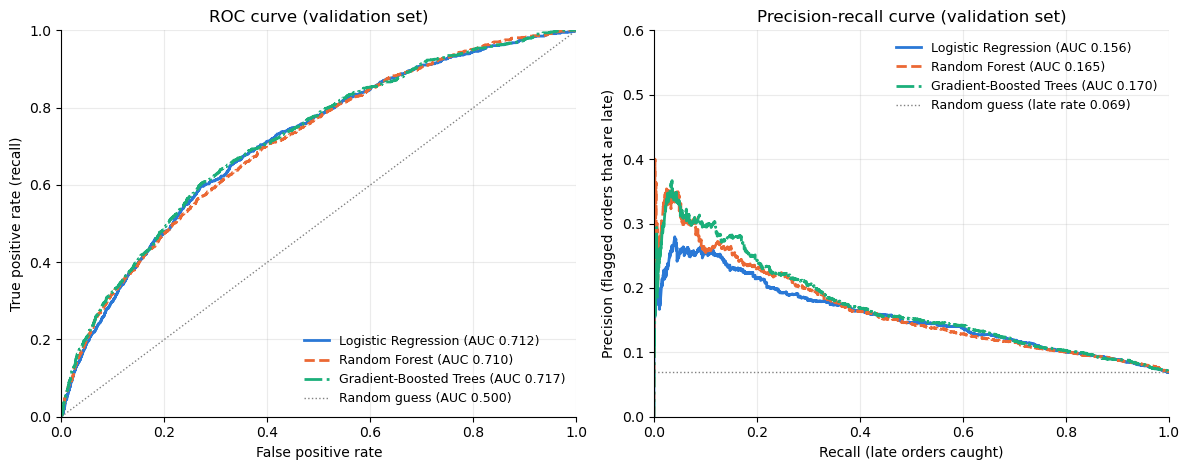

In [35]:
# ---------------------------------------------------------------
# ROC and precision-recall curves on the validation set
# ---------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def validation_scores(model):
    '''Predicted probability of 'late' and the true label, as numpy arrays.'''
    pdf = (model.transform(val_df)
           .select(vector_to_array("probability")[1].alias("p_late"), LABEL_COL)
           .toPandas())
    return pdf["p_late"].to_numpy(), pdf[LABEL_COL].to_numpy()

def curve_points(p, y):
    '''ROC (FPR, TPR) and PR (recall, precision) points, one per ranked order.'''
    order = np.argsort(-p)
    y = y[order]
    tp = np.cumsum(y)
    fp = np.cumsum(1 - y)
    tpr = tp / y.sum()                      # = recall
    fpr = fp / (len(y) - y.sum())
    precision = tp / (tp + fp)
    return fpr, tpr, tpr, precision

COLOURS = {"Logistic Regression": "#2a78d6",      # fixed colour per model
           "Random Forest": "#eb6834",
           "Gradient-Boosted Trees": "#1baf7a"}
STYLES = {"Logistic Regression": "-", "Random Forest": "--", "Gradient-Boosted Trees": "-."}

scores = {name: validation_scores(fitted[name]) for name in models}
late_rate = n_val_late / n_val

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 4.8))
for name, (p, y) in scores.items():
    fpr, tpr, rec, prec = curve_points(p, y)
    ax_roc.plot(fpr, tpr, STYLES[name], color=COLOURS[name], lw=2,
                label=f"{name} (AUC {comparison.loc[name, 'AUC-ROC']:.3f})")
    ax_pr.plot(rec, prec, STYLES[name], color=COLOURS[name], lw=2,
               label=f"{name} (AUC {comparison.loc[name, 'AUC-PR']:.3f})")

ax_roc.plot([0, 1], [0, 1], ":", color="grey", lw=1, label="Random guess (AUC 0.500)")
ax_pr.axhline(late_rate, ls=":", color="grey", lw=1,
              label=f"Random guess (late rate {late_rate:.3f})")

ax_roc.set(title="ROC curve (validation set)", xlabel="False positive rate",
           ylabel="True positive rate (recall)", xlim=(0, 1), ylim=(0, 1))
ax_pr.set(title="Precision-recall curve (validation set)", xlabel="Recall (late orders caught)",
          ylabel="Precision (flagged orders that are late)", xlim=(0, 1), ylim=(0, 0.6))
for ax in (ax_roc, ax_pr):
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="lower right" if ax is ax_roc else "upper right", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

In [36]:
# ---------------------------------------------------------------
# Decision threshold of the best model: the alert trade-off
# ---------------------------------------------------------------
# The model outputs a probability of 'late'. The threshold decides when an
# order is flagged. With class weighting, 0.5 is the default; lowering it
# catches more late orders but raises more false alarms.
p, y = scores[best_name]
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    flagged = p >= t
    tp = int((flagged & (y == 1)).sum())
    fp = int((flagged & (y == 0)).sum())
    fn = int((~flagged & (y == 1)).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    rows.append((t, f"{100 * flagged.mean():.1f}%", tp, fp, fn,
                 round(precision, 3), round(recall, 3), round(f1, 3)))

print(f"{best_name}: effect of the decision threshold on the validation set "
      f"({n_val:,} orders, {n_val_late:,} late)")
pd.DataFrame(rows, columns=["Threshold", "Orders flagged", "Late caught (TP)",
                            "False alarms (FP)", "Late missed (FN)",
                            "Precision", "Recall", "F1"])

Gradient-Boosted Trees: effect of the decision threshold on the validation set (13,579 orders, 936 late)


,Threshold,Orders flagged,Late caught (TP),False alarms (FP),Late missed (FN),Precision,Recall,F1
0,0.3,65.5%,811,8083,125,0.091,0.866,0.165
1,0.4,46.7%,693,5646,243,0.109,0.740,0.191
2,0.5,31.4%,578,3685,358,0.136,0.618,0.222
3,0.6,18.9%,406,2165,530,0.158,0.434,0.232
4,0.7,8.7%,253,926,683,0.215,0.270,0.239


### Results and model choice

**Summary of the comparison** 

| Model | AUC-ROC | AUC-PR | Precision (late) | Recall (late) | F1 (late) | Recall @ top 10% | CV AUC-ROC | CV AUC-PR |
|---|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.7115 | 0.1559 | 0.1273 | **0.6271** | 0.2116 | 0.2756 | 0.7096 ± 0.0042 | 0.1513 ± 0.0069 |
| Random Forest | 0.7097 | 0.1646 | 0.1354 | 0.5513 | 0.2174 | 0.2906 | 0.7076 ± 0.0066 | 0.1597 ± 0.0076 |
| **Gradient-Boosted Trees** | **0.7174** | **0.1703** | **0.1356** | 0.6175 | **0.2224** | **0.2970** | **0.7195 ± 0.0019** | **0.1666 ± 0.0055** |
| Baseline: always "on time" | 0.5000 | 0.0689 | 0 | 0 | 0 | 0.1000 | – | – |

**Chosen model: Gradient-Boosted Trees (GBT).**

1. **It is best on the metrics that matter for imbalanced data.** GBT has the highest AUC-PR (0.1703) and AUC-ROC (0.7174), and the highest F1 for the late class (0.2224). Its AUC-PR is about 2.5 times the 0.0689 a random guess would achieve.
2. **Its lead holds up in cross-validation.** GBT ranks first on both AUC metrics in all checks, and it has the smallest standard deviation (0.0019 for AUC-ROC, 0.0055 for AUC-PR), so its results are the most stable. Its AUC-ROC lead over Logistic Regression (0.0099) is more than twice the fold-to-fold variation. Its AUC-PR lead over Random Forest (0.0069) is smaller, about one standard deviation, but GBT is ahead on every metric, not just one.
3. **It catches the most late orders when the business can only review a few.** If the 10% of orders rated most likely to be late are reviewed, GBT catches 29.7% of all late orders, against 27.6% for Logistic Regression and roughly three times the 10% a random selection would catch.
4. **The trade-offs against the other models favour GBT.**
   - Logistic Regression has slightly higher recall (0.6271 against 0.6175), but only catches 9 more late orders (587 against 578) at the cost of 340 more false alarms (4,025 against 3,685).
   - Random Forest has fewer false alarms (3,295) but misses 62 more late orders (420 against 358). Missing a late order is the more costly error (A.1).
5. **Accuracy was not used to choose.** The "always on time" baseline has the highest accuracy (0.9311) while catching no late orders, which confirms that accuracy is misleading here.

GBT took longer to train (29.1 s against 5.3 s), but training happens once, offline. In Part B the saved model only scores incoming orders, which is fast.

**What drives the model.** The top features are all logistics-related: Olist's promised delivery window (`estimated_delivery_days`, importance 0.152), distance (0.091), the seller's dispatch deadline (0.090), freight cost (0.076) and payment approval time (0.072). This matches the A.2 screening. Customers in RJ also appear in the top 10, consistent with A1's finding that Rio de Janeiro has an above-average late-delivery rate.

**Decision threshold.** The default threshold of 0.5 is kept. It flags 31.4% of orders and catches 61.8% of late ones (578 of 936). Raising it to 0.7 nearly doubles precision (0.215) but catches only 27.0% of late orders. Because recall matters most (A.1), 0.5 is the better balance. If the logistics team could only handle a small number of alerts, 0.7 would be the alternative.

**Limitation.** All three models reach only moderate AUC (about 0.71–0.72). The strongest causes of late delivery, such as carrier disruptions, strikes and weather, are not in the data. The model is therefore best used to rank orders by risk, not as a definite prediction.


## A.5 Model Persistence

The chosen model, Gradient-Boosted Trees, is refitted on the **full training subset** (all 67,274 orders from the 70% training split). In A.3 the models were trained on only 80% of this subset (the fit set, 53,695 orders), because the other 20% was held back to compare them. Now that the model has been chosen, the validation orders are added back, so the final model learns from all the training data. The stream subset is still not used.

In [37]:
# ---------------------------------------------------------------
# Refit the chosen pipeline on the full training subset 
# ---------------------------------------------------------------
from pyspark.ml import PipelineModel

MODEL_PATH = "models/a2_model"
print(f"Chosen model: {best_name}")

# Weights recomputed for the full training subset (same rule as A.3)
print("Full training subset:")
train_w = add_class_weight(train_df)

start = time.time()
bestModel = Pipeline(stages=feature_stages + [models[best_name]]).fit(train_w)
print(f"Refitted on {train_df.count():,} orders in {time.time() - start:.1f} s")

# Save the whole PipelineModel: the 6 feature stages AND the classifier
bestModel.write().overwrite().save(MODEL_PATH)

# Write to disk
stage_dirs = sorted(os.listdir(os.path.join(MODEL_PATH, "stages")))
size_mb = sum(os.path.getsize(os.path.join(root, f))
              for root, _, files in os.walk(MODEL_PATH) for f in files) / 1024**2
print(f"\nSaved to {MODEL_PATH}/ ({size_mb:.2f} MB), {len(stage_dirs)} stages:")
for d in stage_dirs:
    print("  ", d)

Chosen model: Gradient-Boosted Trees
Full training subset:
  67,274 orders, 4,526 late (6.73%) -> weight late = 7.432, on time = 0.536
Refitted on 67,274 orders in 32.4 s

Saved to models/a2_model/ (0.18 MB), 7 stages:
   0_SQLTransformer_53e856e06826
   1_Imputer_81638d5513d7
   2_StringIndexer_46c21e3b05b5
   3_OneHotEncoder_a8811f8b661b
   4_VectorAssembler_f41268835be8
   5_StandardScaler_9fc242088917
   6_GBTClassifier_df5dd259b6c6


In [38]:
# ---------------------------------------------------------------
# Verify: reload the saved model and run a sample .transform()
# ---------------------------------------------------------------
loaded_model = PipelineModel.load(MODEL_PATH)
print("Reloaded stages:")
for i, s in enumerate(loaded_model.stages, 1):
    print(f"  {i}. {type(s).__name__}")

# The columns the model needs as input. These are exactly the fields the
# Kafka producer must send in Part B.
REQUIRED_INPUT_COLS = LOG_FEATURES + RAW_NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Sample: 5 orders with ONLY the identifier and the input columns,
# i.e. no label and no outcome columns, as a new order would arrive.
sample_df = train_df.select("order_id", *REQUIRED_INPUT_COLS).limit(5)
scored = loaded_model.transform(sample_df)

# 1. Output schema: the columns the pipeline adds, with their types
print("\nColumns added by the model:")
for f in scored.schema.fields:
    if f.name in ("features", "rawPrediction", "probability", "prediction"):
        print(f"  {f.name}: {f.dataType.simpleString()}")

expected = {"features": "vector", "rawPrediction": "vector",
            "probability": "vector", "prediction": "double"}
actual = {f.name: f.dataType.simpleString() for f in scored.schema.fields if f.name in expected}
assert actual == expected, f"Unexpected output schema: {actual}"
print("Output schema matches expectations.")

# 2. Sample predictions
(scored.select("order_id",
               F.round(vector_to_array("probability")[1], 4).alias("p_late"),
               "prediction")
 .show(truncate=False))

Reloaded stages:
  1. SQLTransformer
  2. ImputerModel
  3. StringIndexerModel
  4. OneHotEncoderModel
  5. VectorAssembler
  6. StandardScalerModel
  7. GBTClassificationModel

Columns added by the model:
  features: vector
  rawPrediction: vector
  probability: vector
  prediction: double
Output schema matches expectations.
+--------------------------------+------+----------+
|order_id                        |p_late|prediction|
+--------------------------------+------+----------+
|00010242fe8c5a6d1ba2dd792cb16214|0.6562|1.0       |
|00018f77f2f0320c557190d7a144bdd3|0.4087|0.0       |
|00024acbcdf0a6daa1e931b038114c75|0.3814|0.0       |
|00042b26cf59d7ce69dfabb4e55b4fd9|0.0865|0.0       |
|00048cc3ae777c65dbb7d2a0634bc1ea|0.561 |1.0       |
+--------------------------------+------+----------+



In [40]:
# ---------------------------------------------------------------
# Verify: the reloaded model gives identical predictions
# ---------------------------------------------------------------
# Score the validation set with the in-memory model and the reloaded one.
def p_late(model):
    return (model.transform(val_df)
            .select("order_id", vector_to_array("probability")[1].alias("p"), "prediction"))

diff = (p_late(bestModel).alias("a")
        .join(p_late(loaded_model).alias("b"), "order_id")
        .agg(F.count("*").alias("orders"),
             F.max(F.abs(F.col("a.p") - F.col("b.p"))).alias("max_prob_diff"),
             F.sum((F.col("a.prediction") != F.col("b.prediction")).cast("int")).alias("label_mismatches"))
        .first())
print(f"Orders compared: {diff['orders']:,}")
print(f"Largest difference in predicted probability: {diff['max_prob_diff']}")
print(f"Orders with a different predicted label: {diff['label_mismatches']}")
assert diff["max_prob_diff"] == 0 and diff["label_mismatches"] == 0


Orders compared: 13,579
Largest difference in predicted probability: 0.0
Orders with a different predicted label: 0


# Part B: Streaming, Kafka and Reflection


## B.2 Kafka producer

`producer.py` is a standalone script, run from a terminal while this notebook consumes the stream.


**Fields in each record**

| Field | Type in JSON | Purpose |
|---|---|---|
| `order_id` | string | Identifies the order |
| `order_purchase_timestamp` | string (`yyyy-MM-dd HH:mm:ss`) | Original purchase time from the dataset |
| 4 categorical inputs (`customer_state`, `main_seller_state`, `main_category`, `payment_type`) | string | Model inputs |
| 12 numeric inputs (`distance_km`, `total_price`, …, `estimated_delivery_days`) | number | Model inputs. Missing values are sent as `null` and imputed by the pipeline. |
| `is_late` | integer | Actual outcome. **Not used by the model**; sent only to compare predicted and actual late orders per window. |
| `event_timestamp` | string (`yyyy-MM-dd HH:mm:ss`) | Batch publish time, used for windowing and watermarking |

**Why 500 records per batch?** The 28,929 orders become 58 batches, so the replay lasts about 5 minutes (57 pauses × 5 s). That gives enough batches to fill several time windows. Each message is about 275 KB, well under Kafka's 1 MB default limit; at 1,000 records it would be about 550 KB.

## B.3 Spark Structured Streaming consumer

In [9]:
# ---------------------------------------------------------------
# Streaming settings and the explicitly declared message schema
# ---------------------------------------------------------------
import os, shutil, time
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType, DoubleType,
                               IntegerType, LongType, ArrayType)
from pyspark.ml import PipelineModel
from pyspark.ml.functions import vector_to_array

KAFKA_BOOTSTRAP = "kafka:9092"                     # Kafka container on the FIT5202 network
KAFKA_TOPIC = "events"
MODEL_PATH = "models/a2_model"                     
PREDICTIONS_PATH = "output/predictions_parquet"    # Parquet sink
PREDICTIONS_CHECKPOINT = "checkpoints/predictions"
TRIGGER_INTERVAL = "5 seconds"                     # = producer batch interval

# One order record, exactly as producer.py sends it.
# Timestamps arrive as strings (JSON has no timestamp type) and are converted below.
order_schema = StructType([
    StructField("order_id", StringType()),
    StructField("order_purchase_timestamp", StringType()),
    StructField("customer_state", StringType()),
    StructField("main_seller_state", StringType()),
    StructField("main_category", StringType()),
    StructField("payment_type", StringType()),
    StructField("distance_km", DoubleType()),
    StructField("total_price", DoubleType()),
    StructField("total_freight", DoubleType()),
    StructField("total_weight_g", DoubleType()),
    StructField("total_volume_cm3", DoubleType()),
    StructField("shipping_limit_days", DoubleType()),
    StructField("approval_hours", DoubleType()),
    StructField("same_state", IntegerType()),
    StructField("n_items", LongType()),
    StructField("n_sellers", LongType()),
    StructField("payment_installments", IntegerType()),
    StructField("estimated_delivery_days", DoubleType()),
    StructField("is_late", IntegerType()),            # actual outcome, NOT a model input
    StructField("event_timestamp", StringType()),     # added by the producer at publish time
])
# Each Kafka message is a JSON array of order records
batch_schema = ArrayType(order_schema)

# Check: the declared schema has exactly the producer's fields, in the same order
import producer
producer_fields = producer.OUTGOING_FIELDS + ["event_timestamp"]
assert [f.name for f in order_schema.fields] == producer_fields, "Schema does not match producer.py"
print(f"Declared schema matches producer.py: {len(producer_fields)} fields")

Declared schema matches producer.py: 20 fields


In [10]:
# ---------------------------------------------------------------
# Kafka source -> parsed orders -> predictions from the saved model
# ---------------------------------------------------------------
# Fresh run: clear the previous output and checkpoint, so 'latest' applies
for path in (PREDICTIONS_PATH, PREDICTIONS_CHECKPOINT):
    shutil.rmtree(path, ignore_errors=True)

# 1. Read the topic (each Kafka record = one producer batch)
raw_stream = (spark.readStream
              .format("kafka")
              .option("kafka.bootstrap.servers", KAFKA_BOOTSTRAP)
              .option("subscribe", KAFKA_TOPIC)
              .option("startingOffsets", "latest")
              .option("failOnDataLoss", "false")
              .load())

# 2. JSON array -> one row per order, with an explicit schema
orders_stream = (raw_stream
    .select(F.col("offset").alias("kafka_offset"),
            F.explode(F.from_json(F.col("value").cast("string"), batch_schema)).alias("order"))
    .select("kafka_offset", "order.*")
    .withColumn("event_timestamp", F.to_timestamp("event_timestamp", "yyyy-MM-dd HH:mm:ss"))
    .withColumn("order_purchase_timestamp",
                F.to_timestamp("order_purchase_timestamp", "yyyy-MM-dd HH:mm:ss")))

# 3. Load the persisted PipelineModel (no retraining) and score every order
late_model = PipelineModel.load(MODEL_PATH)
print(f"Loaded {MODEL_PATH}: {[type(s).__name__ for s in late_model.stages]}")

predictions_stream = (late_model.transform(orders_stream)
    .select("event_timestamp", "order_id", "order_purchase_timestamp",
            "customer_state", "main_category",
            F.round(vector_to_array("probability")[1], 4).alias("p_late"),   # risk score
            F.col("prediction").cast("int").alias("predicted_late"),         # 1 = predicted late
            F.col("is_late").alias("actual_late"),                           # for checking only
            "kafka_offset"))
predictions_stream.printSchema()

Loaded models/a2_model: ['SQLTransformer', 'ImputerModel', 'StringIndexerModel', 'OneHotEncoderModel', 'VectorAssembler', 'StandardScalerModel', 'GBTClassificationModel']
root
 |-- event_timestamp: timestamp (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- p_late: double (nullable = true)
 |-- predicted_late: integer (nullable = true)
 |-- actual_late: integer (nullable = true)
 |-- kafka_offset: long (nullable = true)



In [11]:
# ---------------------------------------------------------------
# Start the named streaming query: predictions -> Parquet sink
# ---------------------------------------------------------------
predictions_query = (predictions_stream.writeStream
    .queryName("late_delivery_predictions")
    .format("parquet")
    .outputMode("append")
    .option("path", PREDICTIONS_PATH)
    .option("checkpointLocation", PREDICTIONS_CHECKPOINT)
    .trigger(processingTime=TRIGGER_INTERVAL)
    .start())

print(f"Started query '{predictions_query.name}' (id {predictions_query.id})")
print("Now run the producer in the Jupyter terminal:  python producer.py")

Started query 'late_delivery_predictions' (id cfc27ac7-ad0f-4471-8924-0561411ae500)
Now run the producer in the Jupyter terminal:  python producer.py


In [12]:
# ---------------------------------------------------------------
# Monitor the query while producer.py runs
# ---------------------------------------------------------------
def rows_written():
    try:
        return spark.read.parquet(PREDICTIONS_PATH).count()
    except Exception:          # nothing written yet
        return 0

start, last, idle = time.time(), -1, 0
while True:
    time.sleep(15)
    rows = rows_written()
    p = predictions_query.lastProgress
    print(f"[{time.strftime('%H:%M:%S')}] predictions written: {rows:,} | "
          f"last micro-batch id {p['batchId'] if p else '-'}: "
          f"{p['numInputRows'] if p else 0} Kafka message(s) | "
          f"status: {predictions_query.status['message']}")
    idle = idle + 1 if rows == last else 0
    last = rows
    if rows > 0 and idle >= 3:
        print("No new data for 45 s: the producer has finished.")
        break
    if time.time() - start > 900:
        print("Stopped monitoring after 15 minutes.")
        break

[16:12:16] predictions written: 2,500 | last micro-batch id 6: 0 Kafka message(s) | status: Waiting for next trigger
[16:12:31] predictions written: 2,500 | last micro-batch id 6: 0 Kafka message(s) | status: Waiting for next trigger
[16:12:46] predictions written: 2,500 | last micro-batch id 6: 0 Kafka message(s) | status: Waiting for next trigger
[16:13:01] predictions written: 2,500 | last micro-batch id 6: 0 Kafka message(s) | status: Waiting for next trigger
No new data for 45 s: the producer has finished.


In [13]:
# ---------------------------------------------------------------
# What the stream produced (read back from the Parquet sink)
# ---------------------------------------------------------------
results = spark.read.parquet(PREDICTIONS_PATH).cache()

summary = results.agg(
    F.count("*").alias("orders scored"),
    F.countDistinct("event_timestamp").alias("producer batches"),
    F.sum("predicted_late").alias("predicted late"),
    F.sum("actual_late").alias("actually late"),
    F.sum(F.col("predicted_late") * F.col("actual_late")).alias("late and flagged"),
).first().asDict()
summary["recall on stream"] = round(summary["late and flagged"] / summary["actually late"], 3)
summary["precision on stream"] = round(summary["late and flagged"] / summary["predicted late"], 3)
display(pd.DataFrame(summary.items(), columns=["Measure", "Value"]))

# Per producer batch: orders, predicted late, actually late
display(results.groupBy("event_timestamp", "kafka_offset")
        .agg(F.count("*").alias("orders"),
             F.sum("predicted_late").alias("predicted_late"),
             F.sum("actual_late").alias("actual_late"))
        .orderBy("event_timestamp").limit(10).toPandas())

# A few individual predictions, highest risk first
results.orderBy(F.desc("p_late")).select(
    "event_timestamp", "order_id", "customer_state", "main_category",
    "p_late", "predicted_late", "actual_late").show(5, truncate=False)

,Measure,Value
0,orders scored,2500.000
1,producer batches,5.000
2,predicted late,574.000
3,actually late,120.000
4,late and flagged,42.000
5,recall on stream,0.350
6,precision on stream,0.073


,event_timestamp,kafka_offset,orders,predicted_late,actual_late
0,2026-10-04 05:11:26,3,500,21,14
1,2026-10-04 05:11:31,4,500,135,19
2,2026-10-04 05:11:36,5,500,110,23
3,2026-10-04 05:11:41,6,500,144,42
4,2026-10-04 05:11:47,7,500,164,22


+-------------------+--------------------------------+--------------+---------------------+------+--------------+-----------+
|event_timestamp    |order_id                        |customer_state|main_category        |p_late|predicted_late|actual_late|
+-------------------+--------------------------------+--------------+---------------------+------+--------------+-----------+
|2026-10-04 05:11:47|135d65ad3e989409c7acf6ec3a27bd33|RJ            |bed_bath_table       |0.9195|1             |0          |
|2026-10-04 05:11:41|f3d1583d73bad757e13d4e25b24efb32|AL            |watches_gifts        |0.885 |1             |1          |
|2026-10-04 05:11:47|49210ebecdbca0d6aeb2a5e23cbfe9b0|AL            |watches_gifts        |0.8809|1             |1          |
|2026-10-04 05:11:41|ce9a2992255c9322f85dae692b8d4c11|SC            |furniture_decor      |0.8758|1             |0          |
|2026-10-04 05:11:47|fb5d8b462dc9570527eff204b8a1a57b|PA            |computers_accessories|0.8493|1             |0    

In [14]:
# ---------------------------------------------------------------
# Check: streaming predictions = batch predictions for the same orders
# ---------------------------------------------------------------
# Score the same orders straight from stream_data.parquet with the same saved
# model, outside the stream, and compare with what the stream wrote.
batch_scored = (late_model.transform(spark.read.parquet("data/stream_data.parquet"))
                .select("order_id", F.round(vector_to_array("probability")[1], 4).alias("p_batch"),
                        F.col("prediction").cast("int").alias("pred_batch")))

check = (results.join(batch_scored, "order_id")
         .agg(F.count("*").alias("orders compared"),
              F.max(F.abs(F.col("p_late") - F.col("p_batch"))).alias("max probability difference"),
              F.sum((F.col("predicted_late") != F.col("pred_batch")).cast("int")).alias("label mismatches"))
         .first())
display(pd.DataFrame(check.asDict().items(), columns=["Check", "Value"]))

,Check,Value
0,orders compared,2500.0
1,max probability difference,0.0
2,label mismatches,0.0
